## **Ejercicio 1**

### Descripcion
*El dataset contiene información sobre los costumers. Uno de los atributos es ‘Churn’, que es nuestra variable target, la que queremos predecir.* 

*Churn nos dice si el customer dejó de usar el servicio o no en el último mes.*

*Nuestro objetivo es predecir este comportamiento de los customers para lograr retenerlos.*

In [ ]:
import pandas as pd
df = pd.read_csv('info_customers.csv')
df.head()

In [ ]:
df.isna().sum()

### Analisis Exploratorio


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure según Churn")
plt.show()

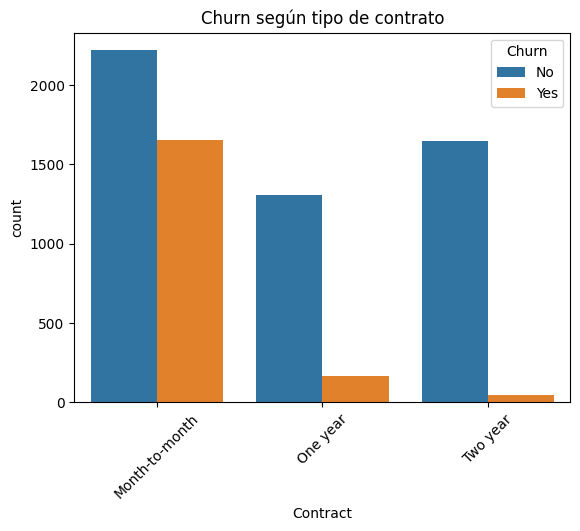

In [ ]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.xticks(rotation=45)
plt.title("Churn según tipo de contrato")
plt.show()

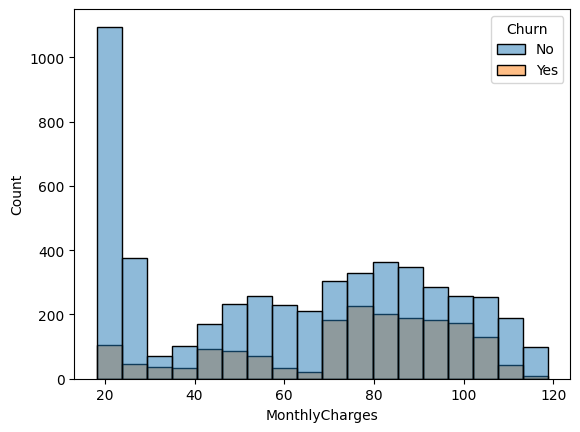

In [ ]:
# Histograma
sns.histplot(x = "MonthlyCharges", hue = "Churn", data = df)

plt.show()

### Algunas columnas no son reconocidas como numericas

*porque*

*solucion*

In [ ]:
# Veo el tipo de dato
df.dtypes

In [ ]:
df.nunique()

In [ ]:
for col in df.columns:
    if col != 'customerID':
        print(f"\nColumna: {col}")
        print(df[col].value_counts())

In [ ]:
df = pd.get_dummies(df, columns=["gender", "Partner", "Dependents", "Contract", "Churn", "PaymentMethod", "PaperlessBilling", "StreamingMovies", "StreamingTV", "TechSupport", "DeviceProtection", "OnlineBackup", "OnlineSecurity", "InternetService", "MultipleLines", "PhoneService"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df = df.drop(columns=["customerID"])
df = df.drop(columns=["Churn_No"])

In [ ]:
df.dtypes

In [ ]:
df['gender_Female'].head(10)

 ## **Ejercicio 2**

*Antes de resolver el problema de los valores nulos, tengo que separar la muestra.*
*Si no, estaria haciendo Data Leakage. Porque estaria usando informacion del test para el training.*

In [ ]:
# Separo Training, Validation y Test
from sklearn.model_selection import train_test_split

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# Training (60%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Validation (20%) y Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


## **Valores Faltantes**

*Tecnica + Justificacion*

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
imputer.fit(X_train)
X_train = imputer.transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)